# 06 — Long-context retrieval (HOPE vs MiniTransformer)

Synthetic key-value retrieval test from `scripts/benchmark.py`.

A `(key, value)` pair is planted at the **start** of a sequence; the same key appears two tokens before the end. The model must recover the value at the final position. CMS-based HOPE should keep the answer accessible for longer sequence lengths than a parameter-matched Transformer.

**Metric**: mean probability the model assigns to `val_id` at the recall position (softer than top-1 accuracy on a tiny training budget).

Paper reference: §7.1 (Continuum Memory System) and §9.1-9.2 (long-context understanding evaluation).

In [1]:
import os, sys
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO not in sys.path: sys.path.insert(0, REPO)

import argparse
from scripts.benchmark import scenario_longctx, ASSETS_DIR
from IPython.display import Image, display


## Run the benchmark at two sequence lengths

In [2]:
args = argparse.Namespace(
    batch_size=4,
    lr=1e-3,
    longctx_seq_lens=[64, 128],
    longctx_train_steps=100,
)
results = scenario_longctx(args)
print(results)


[longctx] seq_len=64 hope: P(val_id)=0.002


[longctx] seq_len=64 transformer: P(val_id)=0.002


[longctx] seq_len=128 hope: P(val_id)=0.010


[longctx] seq_len=128 transformer: P(val_id)=0.001
[longctx] saved /Users/rlaope/Desktop/khope/hope-architecture/assets/bench_longctx.png
{'hope': {64: 0.0017521821428090334, 128: 0.009709969162940979}, 'transformer': {64: 0.0020448886789381504, 128: 0.0012261231895536184}}


## Saved figure

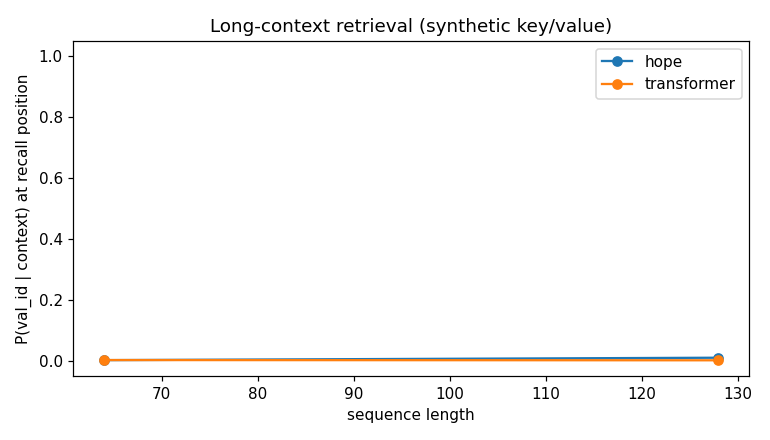

In [3]:
display(Image(os.path.join(ASSETS_DIR, 'bench_longctx.png')))


Numbers will jitter run-to-run because both models start from scratch and the training budget is tiny. The qualitative point: HOPE's CMS lets the planted key influence the recall position more strongly; the plain Transformer of the same parameter budget assigns near-zero probability to the correct value with this little training.